In [3]:
import os

In [4]:
os.getcwd()

'C:\\Users\\PMLS'

In [5]:
os.chdir("C:/Users/PMLS/Desktop/ML & Transcriptiomics")

In [6]:
os.getcwd()

'C:\\Users\\PMLS\\Desktop\\ML & Transcriptiomics'

In [7]:
# Data manipulation 
import pandas as pd
import numpy as np

# Data visualization 
import matplotlib.pyplot as plt
import seaborn as sns 

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Feature Selection 
from sklearn.feature_selection import SelectKBest, f_classif

# Machine Learning Algorithms 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation 
from sklearn.metrics import (
accuracy_score,
confusion_matrix,
ConfusionMatrixDisplay,
classification_report,
roc_auc_score,
roc_curve
)



In [8]:

# load the gene expression matrix
expression_data = pd.read_excel("rna_seq.xlsx")

# Load the metadata
metadata = pd.read_excel("meta_data.xlsx")

print("Datasets loaded")

Datasets loaded


In [9]:
print("Expression Matrix")
display(expression_data.head())

Expression Matrix


,Hugo_Symbol,TCGA-CS-4938-01,TCGA-CS-4941-01,TCGA-CS-4942-01,TCGA-CS-4943-01,TCGA-CS-4944-01,TCGA-CS-5390-01,TCGA-CS-5393-01,TCGA-CS-5394-01,TCGA-CS-5395-01,...,TCGA-VV-A86M-01,TCGA-VW-A7QS-01,TCGA-VW-A8FI-01,TCGA-W9-A837-01,TCGA-WH-A86K-01,TCGA-WY-A858-01,TCGA-WY-A859-01,TCGA-WY-A85A-01,TCGA-WY-A85B-01,TCGA-WY-A85C-01
0,UBE2Q2P2,8.7141,36.4493,11.8131,8.6116,0.000,5.3382,3.7845,8.3071,2.7732,...,10.3069,51.9703,19.1299,12.5770,10.9796,7.8225,3.3371,5.4526,8.2616,11.5121
1,HMGB1P1,22.7523,21.1767,11.0242,5.0835,30.261,27.8886,8.7230,15.4466,12.7776,...,14.2467,47.4612,21.9905,27.0125,14.2608,16.6975,10.2310,16.1890,19.7074,18.7291
2,RNU12-2P,268.5760,156.6870,185.1380,269.8360,216.341,159.7590,198.1880,208.5410,255.2880,...,119.8610,84.7057,127.7470,106.8290,205.5170,184.4080,125.5470,124.9190,133.7390,120.9240
3,SSX9P,845.8150,390.2690,621.4530,835.7290,812.508,576.9050,551.9470,607.8960,386.1780,...,673.5490,1018.6000,564.3620,603.3720,570.9130,760.7160,875.1410,658.2210,662.6510,524.7240
4,EZHIP,0.0000,0.0000,0.0000,0.0000,0.000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [10]:
print("Metadata")
display(metadata.head())

Metadata


,SAMPLE_ID,TUMOR_TYPE
0,TCGA-CS-4938-01,Astrocytoma
1,TCGA-CS-4941-01,Astrocytoma
2,TCGA-CS-4942-01,Astrocytoma
3,TCGA-CS-4943-01,Astrocytoma
4,TCGA-CS-4944-01,Astrocytoma


In [11]:
print("Expression Matrix Shape:", expression_data.shape)
print("Metadata Shape:", metadata.shape)

Expression Matrix Shape: (10000, 384)
Metadata Shape: (383, 2)


In [12]:
print("Expression Matrix Columns")
display(expression_data.columns.tolist())

Expression Matrix Columns


['Hugo_Symbol',
 'TCGA-CS-4938-01',
 'TCGA-CS-4941-01',
 'TCGA-CS-4942-01',
 'TCGA-CS-4943-01',
 'TCGA-CS-4944-01',
 'TCGA-CS-5390-01',
 'TCGA-CS-5393-01',
 'TCGA-CS-5394-01',
 'TCGA-CS-5395-01',
 'TCGA-CS-5396-01',
 'TCGA-CS-5397-01',
 'TCGA-CS-6188-01',
 'TCGA-CS-6290-01',
 'TCGA-CS-6665-01',
 'TCGA-CS-6666-01',
 'TCGA-CS-6667-01',
 'TCGA-CS-6668-01',
 'TCGA-CS-6669-01',
 'TCGA-CS-6670-01',
 'TCGA-DB-5273-01',
 'TCGA-DB-5277-01',
 'TCGA-DB-5278-01',
 'TCGA-DB-5279-01',
 'TCGA-DB-A4XB-01',
 'TCGA-DB-A4XD-01',
 'TCGA-DB-A4XF-01',
 'TCGA-DB-A4XG-01',
 'TCGA-DB-A64L-01',
 'TCGA-DB-A64P-01',
 'TCGA-DB-A64R-01',
 'TCGA-DB-A64V-01',
 'TCGA-DB-A64X-01',
 'TCGA-DB-A75L-01',
 'TCGA-DB-A75M-01',
 'TCGA-DB-A75O-01',
 'TCGA-DB-A75P-01',
 'TCGA-DH-5141-01',
 'TCGA-DH-5142-01',
 'TCGA-DH-5144-01',
 'TCGA-DH-A669-01',
 'TCGA-DH-A66B-01',
 'TCGA-DH-A66D-01',
 'TCGA-DH-A66F-01',
 'TCGA-DH-A66G-01',
 'TCGA-DH-A7UR-01',
 'TCGA-DH-A7US-01',
 'TCGA-DH-A7UT-01',
 'TCGA-DH-A7UU-01',
 'TCGA-DH-A7UV-01',
 'TC

In [13]:
print("Meta data columns")
display(metadata.columns.tolist())

Meta data columns


['SAMPLE_ID', 'TUMOR_TYPE']

In [14]:
print("Expression Matrix Information")
display(expression_data.info())
print("Metadata Information")
display(metadata.info())

Expression Matrix Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 384 entries, Hugo_Symbol to TCGA-WY-A85C-01
dtypes: float64(383), object(1)
memory usage: 29.3+ MB


None

Metadata Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   SAMPLE_ID   383 non-null    object
 1   TUMOR_TYPE  383 non-null    object
dtypes: object(2)
memory usage: 6.1+ KB


None

In [15]:
# Summary of the statistics

display(expression_data.describe())

,TCGA-CS-4938-01,TCGA-CS-4941-01,TCGA-CS-4942-01,TCGA-CS-4943-01,TCGA-CS-4944-01,TCGA-CS-5390-01,TCGA-CS-5393-01,TCGA-CS-5394-01,TCGA-CS-5395-01,TCGA-CS-5396-01,...,TCGA-VV-A86M-01,TCGA-VW-A7QS-01,TCGA-VW-A8FI-01,TCGA-W9-A837-01,TCGA-WH-A86K-01,TCGA-WY-A858-01,TCGA-WY-A859-01,TCGA-WY-A85A-01,TCGA-WY-A85B-01,TCGA-WY-A85C-01
count,1.000000e+04,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.080721e+03,960.220087,934.330608,830.104015,1.405050e+03,835.250791,849.376208,800.989337,941.038624,937.949363,...,800.020536,815.728097,1.008789e+03,859.368144,932.459621,943.552178,846.584024,857.277005,819.694797,854.557786
std,1.703725e+04,7037.299253,7701.750810,3431.189289,3.253433e+04,3123.515581,3444.057315,2478.135742,5252.658259,4231.079010,...,4136.805048,3520.722546,1.171509e+04,3309.618905,6170.890946,9664.028060,2729.647460,3355.562666,4244.670046,4806.112505
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.936900e+00,7.591400,4.152200,3.586800,3.104275e+00,4.381600,4.841600,2.007400,4.813300,3.477250,...,2.790200,3.853900,6.555400e+00,5.865100,4.206700,5.382400,7.107100,4.750600,3.872600,6.130000
50%,1.327880e+02,186.928500,157.958500,147.712000,1.354180e+02,147.878000,164.616000,122.784000,165.875000,135.593000,...,133.091000,126.201000,1.901070e+02,172.777000,152.644000,174.032000,165.915500,156.495500,155.959500,159.787000
75%,7.678837e+02,810.559000,776.125000,775.284250,7.463032e+02,756.549000,778.697000,726.999000,767.912000,765.703000,...,757.394250,770.496250,7.866777e+02,790.964000,767.578250,803.177000,810.288750,774.479000,771.960000,792.092250
max,1.670180e+06,596225.000000,710357.000000,192399.000000,2.554530e+06,150214.000000,200741.000000,71369.000000,374391.000000,226984.000000,...,294434.000000,208930.000000,1.110890e+06,177916.000000,421501.000000,901579.000000,95528.300000,117899.000000,331327.000000,398922.000000


In [16]:
expression_data.describe().to_csv("expression_data_summary.csv", index=True)

In [17]:
metadata["TUMOR_TYPE"].value_counts()

TUMOR_TYPE
Astrocytoma          194
Oligodendroglioma    189
Name: count, dtype: int64

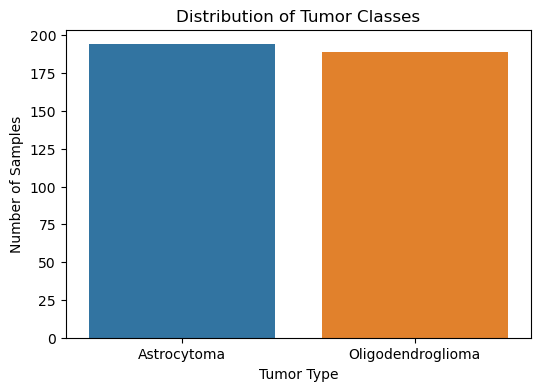

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=metadata,
    x="TUMOR_TYPE",
    hue="TUMOR_TYPE"
)
plt.title("Distribution of Tumor Classes")
plt.xlabel("Tumor Type")
plt.ylabel("Number of Samples")
plt.show()

In [19]:
print("Minimum Expression Value:",
      expression_data.iloc[:,1:].min().min())
print("Maximum Expression Value:",
      expression_data.iloc[:,1:].max().max())

Minimum Expression Value: 0.0
Maximum Expression Value: 2554530.0


In [20]:
print("="*60)
print("Missing Value Assessment")
print("="*60)

before_rows = expression_data.shape[0]
missing_values = expression_data.isnull().sum().sum()

print(f"Total Missing Values: {missing_values}")

expression_data = expression_data.dropna()

after_rows = expression_data.shape[0]

print(f"\nRows Before : {before_rows}")
print(f"Rows After : {after_rows}")
print(f"Rows Removed: {before_rows-after_rows}")

Missing Value Assessment
Total Missing Values: 0

Rows Before : 10000
Rows After : 10000
Rows Removed: 0


In [21]:
print("="*60)
print("Duplicate Row Assessment")
print("="*60)

before_rows = expression_data.shape[0]

duplicates = expression_data.duplicated().sum()

print(f"Duplicate Rows Found: {duplicates}")

expression_data = expression_data.drop_duplicates()

after_rows = expression_data.shape[0]

print(f"\nRows Before : {before_rows}")
print(f"Rows After  : {after_rows}")
print(f"Rows Removed: {before_rows-after_rows}")

Duplicate Row Assessment
Duplicate Rows Found: 0

Rows Before : 10000
Rows After  : 10000
Rows Removed: 0


In [22]:
# Remove lowly expressed genes

# Define the threshold
zero_threshold = 0.60   # Remove genes with >60% zero expression

# Number of genes before filtering
genes_before = expression_data.shape[0]

# Calculate the fraction of samples with zero expression for each gene
zero_fraction = (expression_data.iloc[:, 1:] == 0).mean(axis=1)

# Keep genes with zero expression in less than 60% of the samples
expression_filtered = expression_data[zero_fraction < zero_threshold]

# Number of genes after filtering
genes_after = expression_filtered.shape[0]

# Display summary
print("="*60)
print("Low Expression Filtering Summary")
print("="*60)

print(f"Threshold Used                : {int(zero_threshold*100)}% zeros")
print(f"Minimum Expression Required   : {int((1-zero_threshold)*100)}% of samples")
print(f"Genes Before Filtering        : {genes_before}")
print(f"Genes After Filtering         : {genes_after}")
print(f"Genes Removed                 : {genes_before - genes_after}")
print(f"Percentage Removed            : {(genes_before - genes_before + (genes_before - genes_after))/genes_before*100:.2f}%")
print(f"Percentage Retained           : {(genes_after/genes_before)*100:.2f}%")

Low Expression Filtering Summary
Threshold Used                : 60% zeros
Minimum Expression Required   : 40% of samples
Genes Before Filtering        : 10000
Genes After Filtering         : 8959
Genes Removed                 : 1041
Percentage Removed            : 10.41%
Percentage Retained           : 89.59%


In [23]:
# Inspect filtered dataset

print("="*60)
print("Filtered Dataset Dimensions")

print(f"Number of Genes (Rows)    : {expression_filtered.shape[0]}")
print(f"Number of Samples (Columns): {expression_filtered.shape[1]-1}")

print("\nDataset Shape:", expression_filtered.shape)

Filtered Dataset Dimensions
Number of Genes (Rows)    : 8959
Number of Samples (Columns): 383

Dataset Shape: (8959, 384)


In [24]:
working_dir = r"C:/Users/PMLS/Desktop/ML & Transcriptiomics"
expression_filtered.to_excel(
    os.path.join(working_dir,
                 "01_Low_Expression_Filter.xlsx"), 
    index=False
)

In [25]:
import numpy as np 

# create a copy of filtered dataset
expression_log = expression_filtered.copy()

# expression values before transformation 
before_min = expression_filtered.iloc[:, 1:].min().min()
before_max = expression_filtered.iloc[:, 1:].max().max()

# apply log2(x + 1) transformation
expression_log.iloc[:, 1:] = np.log2(expression_log.iloc[:, 1:] +1)

# Expression values after transformation
after_min = expression_log.iloc[:, 1:].min().min()
after_max = expression_log.iloc[:, 1:].max().max()

print("="*60)
print("Log2 Transformation Summary")
print("="*60)

print(f"Minimum Expression Before : {before_min:.2f}")
print(f"Maximum Expression Before : {before_max:.2f}")

print("-"*60)

print(f"Minimum Expression After  : {after_min:.2f}")
print(f"Maximum Expression After  : {after_max:.2f}")


Log2 Transformation Summary
Minimum Expression Before : 0.00
Maximum Expression Before : 2554530.00
------------------------------------------------------------
Minimum Expression After  : 0.00
Maximum Expression After  : 21.28


In [26]:
expression_log.to_excel(
    os.path.join(working_dir, "02_Log2_Transformed_Data.xlsx"),
    index=False
)

print("Log-transformed dataset saved successfully.")

Log-transformed dataset saved successfully.


In [27]:
# calculate the gene variance 

gene_variance = expression_log.iloc[:, 1:].var(axis=1)
# : select all columns
# 1: select columns, after first column
# axis=1 is row wise calculation

print("="*60)
print("Gene Variance Summary")
print("="*60)

print(gene_variance.describe())

Gene Variance Summary
count    8959.000000
mean        1.084351
std         1.303897
min         0.030628
25%         0.243615
50%         0.607613
75%         1.433307
max        23.131853
dtype: float64


In [28]:
thresholds = [0.1, 0.25, 0.5, 1.0] 

print("="*60)
print(f"{'Threshold':^15}{'Genes Removed':^20}{'Genes Remaining'}")
print("="*60)
 # ^ is for center aligned, and 15 or 20 is for specified width
 # < for left aligned, > right aligned

for threshold in thresholds:

    filtered = expression_log[gene_variance >= threshold]

    removed = expression_log.shape[0] - filtered.shape[0]

    print(f"{threshold:^15}{removed:^20}{filtered.shape[0]}")

   Threshold      Genes Removed    Genes Remaining
      0.1              326         8633
     0.25              2301        6658
      0.5              4033        4926
      1.0              5749        3210


In [29]:
# Remove low Variance Genes 

# Selected Variance Threshold
variance_threshold = 0.50

# Calculate Variance for Each Gene 
gene_variance = expression_log.iloc[:, 1:].var(axis=1)

# Filter genes 
expression_variance_filtered = expression_log[
    gene_variance >= variance_threshold
    ]
# Summary 
genes_before = expression_log.shape[0]
genes_after = expression_variance_filtered.shape[0]

print("="*60)
print("Low Variance Filtering Summary")
print("="*60)

print(f"Variance Threshold Used     : {variance_threshold}")
print(f"Genes Before Filtering      : {genes_before}")
print(f"Genes After Filtering       : {genes_after}")
print(f"Genes Removed               : {genes_before - genes_after}")
print(f"Percentage Removed          : {((genes_before - genes_after)/genes_before)*100:.2f}%")
print(f"Percentage Retained         : {(genes_after/genes_before)*100:.2f}%")

Low Variance Filtering Summary
Variance Threshold Used     : 0.5
Genes Before Filtering      : 8959
Genes After Filtering       : 4926
Genes Removed               : 4033
Percentage Removed          : 45.02%
Percentage Retained         : 54.98%


In [30]:
# Save the variance-filtered dataset 

expression_variance_filtered.to_excel(
    os.path.join(working_dir, "03_Variance_Filtered_Data.xlsx"),
    index=False
)

print("Variance-filtered dataset saved successfully.")

Variance-filtered dataset saved successfully.


In [31]:
# Prepare Dataset for Correlation

# Set Gene ID as index 
correlation_data = expression_variance_filtered.set_index(
    expression_variance_filtered.columns[0]
)

print("="*60)
print("Dataset for Correlation Analysis")
print("="*60)

print(f"Genes   : {correlation_data.shape[0]}")
print(f"Samples : {correlation_data.shape[1]}")

correlation_data.head()

Dataset for Correlation Analysis
Genes   : 4926
Samples : 383


,TCGA-CS-4938-01,TCGA-CS-4941-01,TCGA-CS-4942-01,TCGA-CS-4943-01,TCGA-CS-4944-01,TCGA-CS-5390-01,TCGA-CS-5393-01,TCGA-CS-5394-01,TCGA-CS-5395-01,TCGA-CS-5396-01,...,TCGA-VV-A86M-01,TCGA-VW-A7QS-01,TCGA-VW-A8FI-01,TCGA-W9-A837-01,TCGA-WH-A86K-01,TCGA-WY-A858-01,TCGA-WY-A859-01,TCGA-WY-A85A-01,TCGA-WY-A85B-01,TCGA-WY-A85C-01
Hugo_Symbol,,,,,,,,,,,,,,,,,,,,,
UBE2Q2P2,3.280080,5.226867,3.679548,3.264777,0.000000,2.664073,2.258368,3.218332,1.915789,3.214560,...,3.499132,5.727112,4.331268,3.763093,3.582508,3.141188,2.116731,2.689881,3.211261,3.645252
HMGB1P1,4.569995,4.470973,3.587869,2.604902,4.966292,4.852428,3.281402,4.039717,3.784253,4.388203,...,3.930425,5.598758,4.522966,4.807999,3.931759,4.145474,3.489414,4.103414,4.372075,4.302253
EFCAB8,7.519676,8.348958,7.045945,6.400453,6.352194,7.765018,8.379621,7.939949,7.548737,7.801566,...,9.213430,10.218079,10.177083,8.495739,9.318814,9.701970,8.788836,9.080849,9.255395,9.712114
REXO1L6P,1.631244,2.154032,1.448954,1.204329,2.009383,3.287339,1.935196,1.588517,0.000000,1.911078,...,3.604154,4.592373,3.756479,3.120667,1.138749,3.481144,3.418392,3.068636,3.607342,3.856577
A2BP1,8.304160,9.083235,8.603215,8.665279,6.535924,8.160714,8.398718,9.004350,9.254585,9.049508,...,7.653454,7.721373,7.339013,8.489864,8.146961,7.204786,7.581946,8.497920,8.057938,7.520996


In [32]:
# Calculate Gene Correlation Matrix
# correlation matrix shows how strongly different variables are related to each other
# Transpose the Matrix so that gene become columns
correlation_matrix = correlation_data.T.corr(method="pearson")

print("="*60)
print("Correlation Matrix")
print("="*60)

print(f"Shape : {correlation_matrix.shape}")


Correlation Matrix
Shape : (4926, 4926)


In [33]:
# Inspect the correlation matrix
print("="*60)
print("Correlation Matrix Overview")
print("="*60)

print(f"Number of Genes              : {correlation_matrix.shape[0]}")
print(f"Number of Correlation Values : {correlation_matrix.size:,}")
print(f"Matrix Shape                 : {correlation_matrix.shape}")

Correlation Matrix Overview
Number of Genes              : 4926
Number of Correlation Values : 24,265,476
Matrix Shape                 : (4926, 4926)


In [34]:
# Display the first 10 rows and columns
correlation_matrix.iloc[:10, :10]

Hugo_Symbol,UBE2Q2P2,HMGB1P1,EFCAB8,REXO1L6P,A2BP1,A2LD1,A2M,A2ML1,A4GNT,AAA1
Hugo_Symbol,,,,,,,,,,
UBE2Q2P2,1.000000,0.434770,0.336368,0.091031,0.377579,0.438513,0.186488,-0.147520,-0.091253,0.217265
HMGB1P1,0.434770,1.000000,0.190075,0.230961,0.015421,0.185462,0.054656,-0.096910,0.074571,-0.015607
EFCAB8,0.336368,0.190075,1.000000,0.390579,-0.132605,0.573989,-0.115624,0.040885,-0.070669,0.289349
REXO1L6P,0.091031,0.230961,0.390579,1.000000,-0.256454,0.294144,-0.158923,-0.161313,-0.022378,0.124187
A2BP1,0.377579,0.015421,-0.132605,-0.256454,1.000000,0.221490,0.372175,-0.181953,-0.050241,0.178501
A2LD1,0.438513,0.185462,0.573989,0.294144,0.221490,1.000000,0.103066,-0.267499,0.119809,0.444516
A2M,0.186488,0.054656,-0.115624,-0.158923,0.372175,0.103066,1.000000,-0.230425,0.180109,0.152411
A2ML1,-0.147520,-0.096910,0.040885,-0.161313,-0.181953,-0.267499,-0.230425,1.000000,-0.244808,-0.217724
A4GNT,-0.091253,0.074571,-0.070669,-0.022378,-0.050241,0.119809,0.180109,-0.244808,1.000000,-0.040006


In [35]:
# Check Diagonal Values

diagonal_values = np.diag(correlation_matrix)


print("="*60)
print("Diagonal Inspection")
print("="*60)

print("Unique values on diagonal:")

print(np.unique(diagonal_values))

Diagonal Inspection
Unique values on diagonal:
[1.]


In [36]:
# Extract Upper Triangle

upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

correlation_values = upper_triangle.stack()
correlation_values = upper_triangle.stack()
print("="*70)
print("Unique Gene Pair Correlations")
print("="*70)

print(f"Total Unique Gene Pairs : {len(correlation_values):,}")

Unique Gene Pair Correlations
Total Unique Gene Pairs : 12,130,275


In [37]:

print("="*60)
print("Correlation Summary")
print("="*60)

print(correlation_values.describe())

Correlation Summary
count    1.213028e+07
mean     4.147844e-02
std      2.276056e-01
min     -8.510756e-01
25%     -1.084614e-01
50%      3.054765e-02
75%      1.815535e-01
max      9.937188e-01
dtype: float64


In [38]:
thresholds = [0.80, 0.85, 0.90, 0.95]

print("="*65)
print(f"{'Threshold':<9.5}"
      f"{'Correlated Pairs':<22}"
      f"{'Genes Removed':<20}"
      f"{'Genes Remaining'}")
print("="*65)

total_genes = correlation_matrix.shape[0]

for threshold in thresholds:

    # Select upper triangle only
    upper = correlation_matrix.where(
        np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
    )

    # Find genes to remove
    to_drop = [
        column for column in upper.columns
        if any(upper[column] > threshold)
    ]

    genes_removed = len(to_drop)
    genes_remaining = total_genes - genes_removed

    # Count correlated gene pairs
    correlated_pairs = (
        upper.stack() > threshold
    ).sum()

    print(f"{threshold:<9.5}"
          f"{correlated_pairs:<22}"
          f"{genes_removed:<20}"
          f"{genes_remaining}")

Thres    Correlated Pairs      Genes Removed       Genes Remaining
0.8      15030                 924                 4002
0.85     6051                  533                 4393
0.9      1502                  243                 4683
0.95     75                    41                  4885


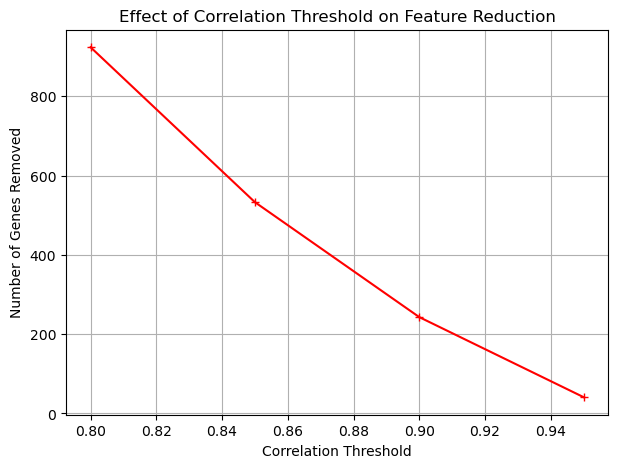

In [39]:
removed_counts = []

for threshold in thresholds:
    upper = correlation_matrix.where(
        np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
    )
    to_drop = [
        column for column in upper.columns
        if any(upper[column] > threshold)
    ]

    removed_counts.append(len(to_drop))
plt.figure(figsize=(7,5))

plt.plot(thresholds, removed_counts, marker='+', color="red")
plt.xlabel("Correlation Threshold")
plt.ylabel("Number of Genes Removed")
plt.title("Effect of Correlation Threshold on Feature Reduction")

plt.grid(True)

plt.show()
    

In [40]:
# Correlation threshold
correlation_threshold = 0.85

# Select upper triangle of the correlation matrix
upper = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

# Identify genes to remove
genes_to_remove = [
    column for column in upper.columns
    if any(upper[column] > correlation_threshold)
]

# Remove redundant genes
expression_correlation_filtered = correlation_data.drop(index=genes_to_remove)

print("=" * 60)
print("Correlation Filtering Summary")
print("=" * 60)
print(f"Correlation Method        : Pearson")
print(f"Threshold Used            : {correlation_threshold}")
print(f"Genes Before Filtering    : {correlation_data.shape[0]}")
print(f"Genes Removed             : {len(genes_to_remove)}")
print(f"Genes Remaining           : {expression_correlation_filtered.shape[0]}")
print(f"Percentage Removed        : {len(genes_to_remove)/correlation_data.shape[0]*100:.2f}%")
print(f"Percentage Retained       : {expression_correlation_filtered.shape[0]/correlation_data.shape[0]*100:.2f}%")

Correlation Filtering Summary
Correlation Method        : Pearson
Threshold Used            : 0.85
Genes Before Filtering    : 4926
Genes Removed             : 533
Genes Remaining           : 4393
Percentage Removed        : 10.82%
Percentage Retained       : 89.18%


In [41]:
# Save the refined Dataset

# Convert Gene IDs to a column
expression_correlation_filtered = expression_correlation_filtered.reset_index()

# Save as Excel Sheet
expression_correlation_filtered.to_excel(
    "Expression_Data_Correlation_Filtered.xlsx",
    index=False
)
print("\nRefined dataset saved successfully!")
print(f"Final Dataset Shape: {expression_correlation_filtered.shape}")


Refined dataset saved successfully!
Final Dataset Shape: (4393, 384)


In [42]:
# Load files
expression_data = pd.read_excel("Expression_Data_Correlation_Filtered.xlsx")
metadata = pd.read_excel("meta_data.xlsx")

# Set Gene IDs as index
expression_data = expression_data.set_index(expression_data.columns[0])

# Transpose expression matrix
expression_ml = expression_data.T

# Merge with metadata
merged_data = expression_ml.merge(
    metadata,
    left_index=True,
    right_on="SAMPLE_ID",
    how="inner"
)

print("="*70)
print("Dataset Successfully Merged")
print("="*70)

print("Merged Dataset Shape:", merged_data.shape)

Dataset Successfully Merged
Merged Dataset Shape: (383, 4395)


In [43]:
print("="*60)
print("Machine Learning Dataset Summary")
print("="*60)

print(f"Number of Samples : {merged_data.shape[0]}")

print(f"Number of Columns : {merged_data.shape[1]}")

print()

print("Tumor Types")

print(merged_data["TUMOR_TYPE"].value_counts())

print()

print("Missing Labels")

print(merged_data["TUMOR_TYPE"].isna().sum())

Machine Learning Dataset Summary
Number of Samples : 383
Number of Columns : 4395

Tumor Types
TUMOR_TYPE
Astrocytoma          194
Oligodendroglioma    189
Name: count, dtype: int64

Missing Labels
0


In [44]:
# Label encoding 

label_map = {
    "Astrocytoma": 0, 
    "Oligodendroglioma": 1
}

merged_data["Class"] = merged_data["TUMOR_TYPE"].map(label_map)

print("Encoded Class Distribution")

print(merged_data["Class"].value_counts())

Encoded Class Distribution
Class
0    194
1    189
Name: count, dtype: int64


In [45]:
# Create Feature Matrix and Target Vector 

X = merged_data.drop(
    columns=[
        "SAMPLE_ID",
        "TUMOR_TYPE",
        "Class"
    ]
)

y = merged_data["Class"]

print("Machine Learning Dataset")

print("Feature Matrix Shape :", X.shape)

print("Target Shape:", y.shape)

Machine Learning Dataset
Feature Matrix Shape : (383, 4393)
Target Shape: (383,)


In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20, #20% set for testing
    stratify=y, # similar class proportion in training and testing
    random_state=42
)

print("Train-Test Split Summary")

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

print(f"Training features: {X_train.shape[1]}")
print(f"Testing features: {X_test.shape[1]}")

Train-Test Split Summary
Training samples: 306
Testing samples: 77
Training features: 4393
Testing features: 4393


In [47]:
print("\nTraining Set Class Distribution")
print(y_train.value_counts())

print("\nTesting Set Class Distribution")
print(y_test.value_counts())


Training Set Class Distribution
Class
0    155
1    151
Name: count, dtype: int64

Testing Set Class Distribution
Class
0    39
1    38
Name: count, dtype: int64


In [48]:
from sklearn.feature_selection import f_classif 
# f_class if compares the features with the target/class

In [51]:
F_score, p_value = f_classif (X_train, y_train)

print ("ANOVA Performed Successfully")

print("Total genes evaluated:", len(F_score))

ANOVA Performed Successfully
Total genes evaluated: 4393


In [54]:
# Create feature ranking table

anova_results = pd.DataFrame({
    "Genes": X_train.columns,
    "F_score": F_score,
    "P_Value": p_value
})

anova_results = anova_results.sort_values(
    by="F_score",
    ascending=False
).reset_index(drop=True)

anova_results.head(20)

,Genes,F_score,P_Value
0,ASB3,206.407553,4.446954e-36
1,HDGF,184.479221,3.643053e-33
2,CNOT6L,178.323197,2.530523e-32
3,DOLPP1,162.585658,4.033390e-30
4,GRLF1,151.507289,1.591727e-28
5,FNTB,145.021938,1.428080e-27
6,HSCB,141.545171,4.692320e-27
7,FAM198A,139.979370,8.042781e-27
8,KCNJ8,139.858436,8.385243e-27
9,C2orf79,137.331648,2.009324e-26


In [63]:
thresholds = [0.05, 0.01, 0.001, 0.0001]

print("Significant Genes at Different P_Value Thresholds")

for threshold in thresholds:
    count = (anova_results["P_Value"] < threshold).sum()
    print(f"P-value < [threshold:<8] : {count} genes")

Significant Genes at Different P_Value Thresholds
P-value < [threshold:<8] : 2875 genes
P-value < [threshold:<8] : 2434 genes
P-value < [threshold:<8] : 1944 genes
P-value < [threshold:<8] : 1559 genes


In [66]:
significant_genes = anova_results[
    anova_results["P_Value"] <= 0.05
    ].copy()

print("Statistically Signifcant Genes")

print(f"Total significant genes: {significant_genes.shape[0]}")
print(f"Total non-significant genes: {anova_results.shape[0]-significant_genes.shape[0]}")

Statistically Signifcant Genes
Total significant genes: 2875
Total non-significant genes: 1518


In [67]:
# Significant genes Data Frame Summar

significant_genes.describe()

,F_score,P_Value
count,2875.000000,2.875000e+03
mean,26.204871,4.832242e-03
std,24.368528,1.045902e-02
min,3.875495,4.446954e-36
25%,8.982343,8.487839e-09
50%,17.197874,4.374291e-05
75%,35.096456,2.950730e-03
max,206.407553,4.990411e-02


In [68]:
significant_genes.head(20)

,Genes,F_score,P_Value
0,ASB3,206.407553,4.446954e-36
1,HDGF,184.479221,3.643053e-33
2,CNOT6L,178.323197,2.530523e-32
3,DOLPP1,162.585658,4.033390e-30
4,GRLF1,151.507289,1.591727e-28
5,FNTB,145.021938,1.428080e-27
6,HSCB,141.545171,4.692320e-27
7,FAM198A,139.979370,8.042781e-27
8,KCNJ8,139.858436,8.385243e-27
9,C2orf79,137.331648,2.009324e-26


In [69]:
significant_genes.to_excel(
    "ANOVA_Significant_Genes.xlsx",
    index=False
)

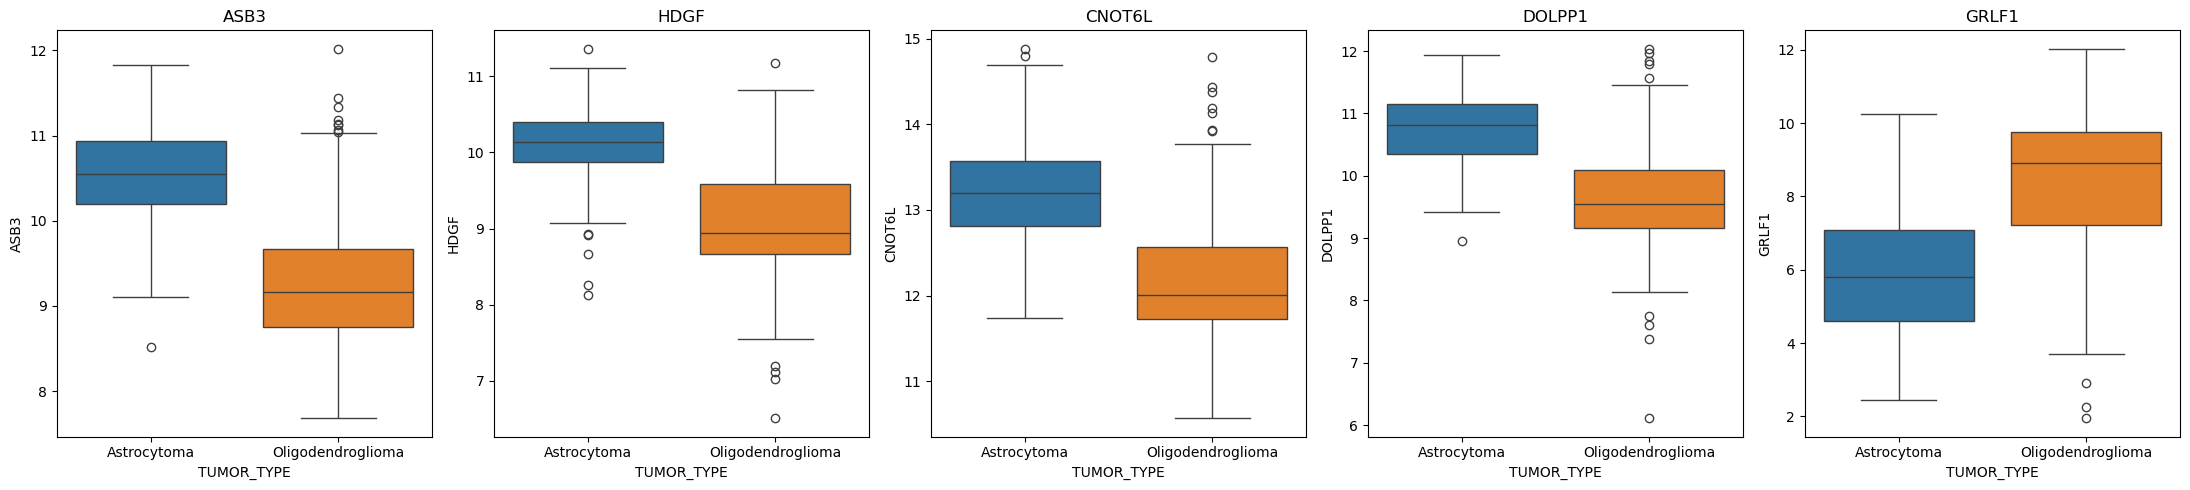

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

top5 = significant_genes.head(5)["Genes"]

fig, axes = plt.subplots(1,5, figsize=(22,5))

for i,gene in enumerate(top5):

    sns.boxplot(
        x=merged_data["TUMOR_TYPE"],
        y=merged_data[gene],
        hue=merged_data["TUMOR_TYPE"],
        ax=axes[i]
    )

    axes[i].set_title(gene)

plt.tight_layout()
plt.show()

In [82]:
k = 500

print("Feature Selection Parameter")

print(f"Top{k} genes will be selected for machine learning.")

Feature Selection Parameter
Top500 genes will be selected for machine learning.


In [83]:
selected_genes = significant_genes.head(k)["Genes"]

X_train_selected = X_train[selected_genes]

X_test_selected = X_test[selected_genes]

print("Final Machine Learning Dataset")

print(f"Training Set : {X_train_selected.shape}")
print(f"Testing Set  : {X_test_selected.shape}")

Final Machine Learning Dataset
Training Set : (306, 500)
Testing Set  : (77, 500)


In [84]:
X_train_selected.to_excel(
    f"X_Train_Top_{k}_Genes.xlsx"
)

X_test_selected.to_excel(
    f"X_Test_Top_{k}_Genes.xlsx"
)

print("Dataset saved successfully")

Dataset saved successfully


In [87]:
# Import Standard Scaler
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit only training dataset
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

print("Feature Standardization Completed")

print("Training Shape:", X_train_scaled.shape)
print("Testing Shape:", X_test_scaled.shape)

Feature Standardization Completed
Training Shape: (306, 500)
Testing Shape: (77, 500)


In [88]:
import pandas as pd

scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train_selected.columns
)

print("Summary Statistics")
print(scaled_df.iloc[:, :5].describe().loc[["mean", "std"]])

Summary Statistics
              ASB3          HDGF        CNOT6L        DOLPP1         GRLF1
mean -1.567374e-16  9.984751e-16  5.993753e-16 -9.984751e-16  8.127123e-17
std   1.001638e+00  1.001638e+00  1.001638e+00  1.001638e+00  1.001638e+00


In [ ]:
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    index=X_train_selected.index,
    columns=X_train_selected.columns
)

# Convert testing data
X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    index=X_test_selected.index,
    columns=X_test_selected.columns
)

print("="*70)
print("Scaled Training Dataset")
print("="*70)

print(X_train_scaled_df.head())

In [92]:
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    index=X_train_selected.index,
    columns=X_train_selected.columns,
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    index=X_test_selected.index,
    columns=X_train_selected.columns,
)

print("Scaled Training Dataset")

print(X_train_scaled_df.head())

Scaled Training Dataset
         ASB3      HDGF    CNOT6L    DOLPP1     GRLF1      FNTB      HSCB  \
316 -0.853438 -0.355866 -1.182310 -0.659593  1.340348 -0.945932 -0.919168   
100 -0.522805 -0.451314  0.037124 -0.298418 -0.149657  0.589234 -0.263643   
362  1.069216  0.691649 -0.042058  0.369192  0.367161  0.749857  0.546267   
317 -1.485478 -1.015152 -1.040930 -1.498936  0.910351 -1.424335 -1.343494   
209 -0.118154  1.298354  1.220663  0.604553 -1.408074 -0.499327  0.927290   

      FAM198A     KCNJ8   C2orf79  ...  LINC00930     IL17B     C2CD3  \
316  0.915109  0.882630 -0.971567  ...   0.744661  1.063185  0.571123   
100  0.075395  0.807099 -0.144657  ...   1.104269  2.492627 -0.668153   
362 -0.701722  0.053027  0.918747  ...   0.617891  0.489726  0.193921   
317  0.548081  1.073524 -0.712141  ...  -0.416525 -0.166430  1.288813   
209 -1.098427 -2.021433 -0.371630  ...  -1.150513 -0.534937 -2.755518   

        FOLR2     BUD13       CKM   HMGB1P1    ADAM10      EMR1     CASC3 

In [93]:
X_train_scaled_df.to_excel(
    f"X_train_Top_{k}_Scaled.xlsx"
)

X_test_scaled_df.to_excel(
    f"X_test_Top_{k}_Scaled.xlsx"
)

In [94]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [96]:
# Define KNN Hyperparameter

n_neighbors = 5

print("KNN Hyperparameter")

print(f"Number of Neighbors (k) : {n_neighbors}")

KNN Hyperparameter
Number of Neighbors (k) : 5


In [97]:
# Initialize KNN Model

knn_model = KNeighborsClassifier( #KNN Classification Algorithm
    n_neighbors=n_neighbors
)

print(knn_model)

KNeighborsClassifier()


In [98]:
# Train the KNN Model

knn_model.fit(
    X_train_scaled_df,
    y_train
)

print("KNN model trained successfully")

KNN model trained successfully


In [99]:
# Predict the cancer classes

y_pred_knn = knn_model.predict(
    X_test_scaled_df
)

print("Prediction Completed")

print(f"Total Test Samples: {len(y_test)}")

Prediction Completed
Total Test Samples: 77


In [100]:
# Model Performance Metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

accuracy = accuracy_score(y_test, y_pred_knn)
precision = precision_score(y_test, y_pred_knn, average='weighted')
recall = recall_score(y_test, y_pred_knn, average='weighted')
f1 = f1_score(y_test, y_pred_knn, average='weighted')

print("KNN Performance Metrics")

print(f"Accuracy: {accuracy: .4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall: .4f}")
print(f"f1: {f1: .4f}")

KNN Performance Metrics
Accuracy:  0.8312 (83.12%)
Precision: 0.8421
Recall:  0.8312
f1:  0.8296


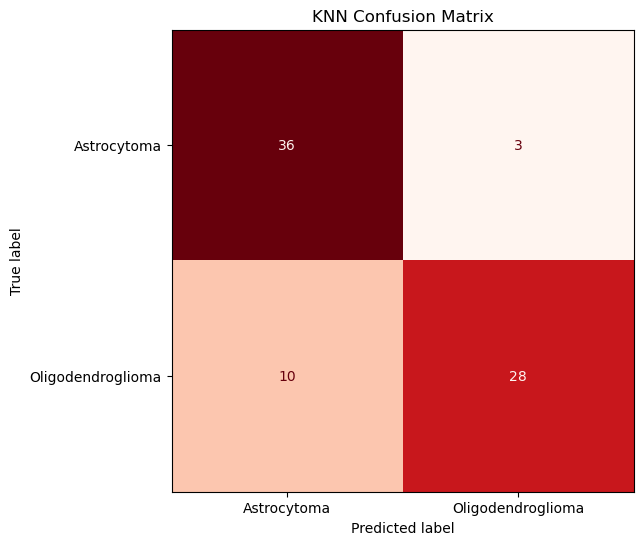

In [104]:
cm = confusion_matrix(
    y_test,
    y_pred_knn
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Astrocytoma", "Oligodendroglioma"],
)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(
    cmap="Reds",
    ax=ax,
    colorbar=False
)

plt.title("KNN Confusion Matrix")

plt.grid(False)

plt.show()

In [106]:

comparison = pd.DataFrame({
    "Actual": y_test,
    "Prediced": y_pred_knn
})

comparison.head(10)

,Actual,Prediced
219,1,1
375,0,0
267,0,0
139,1,1
137,1,1
248,1,1
227,0,0
351,1,1
275,0,0
107,0,1


In [108]:
comparison.to_excel(
    "KNN_Predicted.xlsx",
    index=False
)

In [110]:
# import ROC curve and AUC
from sklearn.metrics import roc_curve, roc_auc_score

y_prob_knn = knn_model.predict_proba(X_test_scaled_df)[:, 1]

# Compute ROC

fpr, tpr, thresholds = roc_curve(y_test, y_prob_knn)

auc_score = roc_auc_score(y_test, y_prob_knn)

print("ROC Analysis")

print(f"AUC Score : {auc_score:.4f}")

ROC Analysis
AUC Score : 0.8812


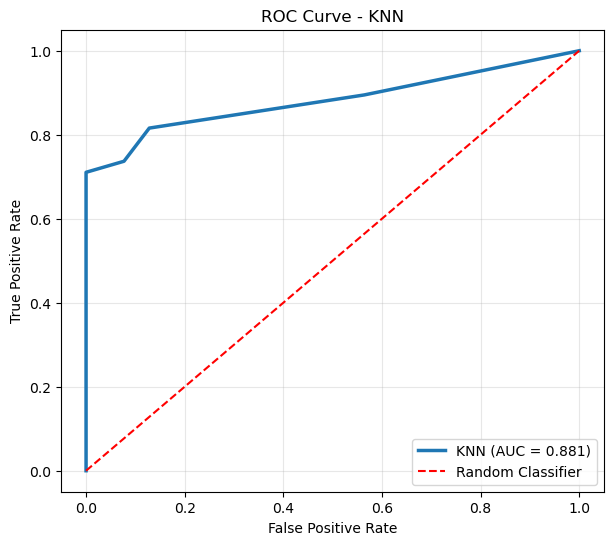

In [113]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2.5,
    label=f"KNN (AUC = {auc_score:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="red",
    label="Random Classifier"
)


plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - KNN")

plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.show()

In [114]:
summary = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "AUC"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        f1,
        auc_score
    ]

})

summary["Value"] = summary["Value"].round(4)

summary

,Metric,Value
0,Accuracy,0.8312
1,Precision,0.8421
2,Recall,0.8312
3,F1-score,0.8296
4,AUC,0.8812


In [115]:
summary.to_excel("KNN_Performance.xlsx", index=False)

In [116]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

import matplotlib.pyplot as plt

In [117]:
# Define Decision Tree Parameters

max_depth = 5
criterion = "gini" # which split class separates the best
random_state = 42

In [118]:
# Initialize Decision Tree Model

dt_model = DecisionTreeClassifier(
    criterion=criterion,
    max_depth=max_depth,
    random_state=random_state
)

print(dt_model)







DecisionTreeClassifier(max_depth=5, random_state=42)


In [119]:

# Train the dt_model

dt_model.fit(
    X_train_selected,
    y_train
)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


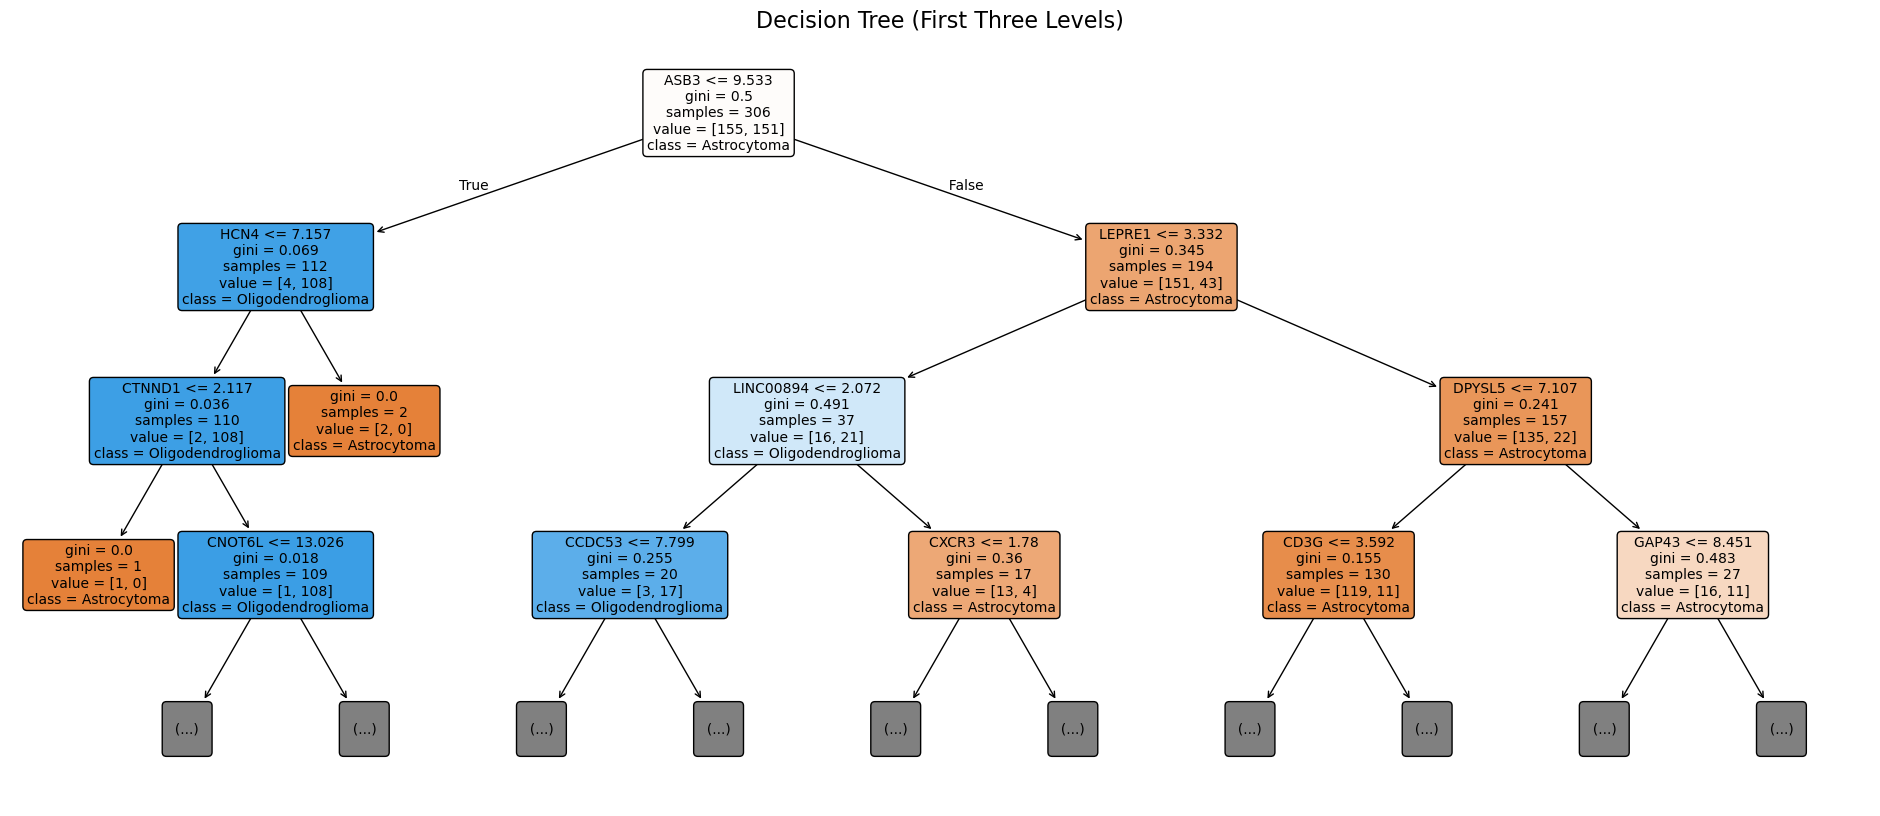

In [121]:
# Visualize the Decision Tree

plt.figure(figsize=(25,10))

plot_tree(
    dt_model,
    feature_names=X_train_selected.columns,
    class_names=["Astrocytoma","Oligodendroglioma"],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3
)
plt.title("Decision Tree (First Three Levels)", fontsize=16)

plt.show()

In [122]:
# Predict Test Samples

y_pred_dt = dt_model.predict(
    X_test_selected)



In [123]:
# Evaluate Model Performance

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt, average="weighted")
dt_recall = recall_score(y_test, y_pred_dt, average="weighted")
dt_f1 = f1_score(y_test, y_pred_dt, average="weighted")

print("="*70)
print("Decision Tree Performance Metrics")
print("="*70)

print(f"Accuracy : {dt_accuracy:.4f} ({dt_accuracy*100:.2f}%)")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1 Score : {dt_f1:.4f}")

Decision Tree Performance Metrics
Accuracy : 0.8312 (83.12%)
Precision: 0.8330
Recall   : 0.8312
F1 Score : 0.8308


In [124]:
print("Classification Report")

print(classification_report(y_test, y_pred_dt))

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.87      0.84        39
           1       0.86      0.79      0.82        38

    accuracy                           0.83        77
   macro avg       0.83      0.83      0.83        77
weighted avg       0.83      0.83      0.83        77



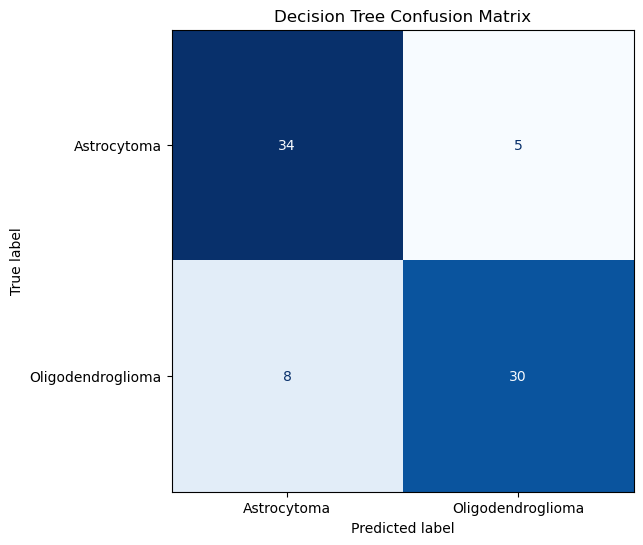

In [127]:
# Generate Confusion Matrix

cm_dt = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["Astrocytoma", "Oligodendroglioma"]
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Decision Tree Confusion Matrix")

plt.grid(False)

plt.show()

In [128]:
y_prob_dt = dt_model.predict_proba(X_test_selected)[:, 1]



In [129]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_prob_dt)

# Calculate AUC
dt_auc = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree ROC Analysis")


print(f"AUC Score : {dt_auc:.4f}")

Decision Tree ROC Analysis
AUC Score : 0.8327


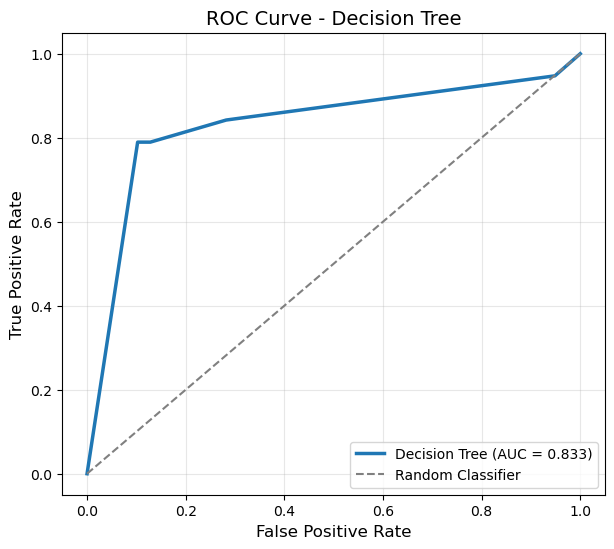

In [130]:
# Plot ROC Curve

plt.figure(figsize=(7,6))

plt.plot(
    fpr_dt,
    tpr_dt,
    linewidth=2.5,
    label=f"Decision Tree (AUC = {dt_auc:.3f})"
)

# Random classifier
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve - Decision Tree", fontsize=14)

plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.show()

In [131]:
dt_predictions = pd.DataFrame({

    "Actual": y_test,
    "Predicted": y_pred_dt

})

print("="*70)
print("Decision Tree Predictions")
print("="*70)

display(dt_predictions.head(20))

Decision Tree Predictions


,Actual,Predicted
219,1,1
375,0,0
267,0,0
139,1,1
137,1,1
248,1,1
227,0,0
351,1,1
275,0,0
107,0,0


In [132]:
# dt Predictions Summar


dt_summary = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "AUC"
    ],

    "Value":[
        dt_accuracy,
        dt_precision,
        dt_recall,
        dt_f1,
        dt_auc
    ]

})

dt_summary["Value"] = dt_summary["Value"].round(4)

dt_summary

,Metric,Value
0,Accuracy,0.8312
1,Precision,0.8330
2,Recall,0.8312
3,F1-score,0.8308
4,AUC,0.8327


In [133]:
# Save dt summary to excel file


dt_summary.to_excel(
    "DecisionTree_Performance.xlsx",
    index=False
)

dt_predictions.to_excel(
    "DecisionTree_Predictions.xlsx",
    index=False
)

In [134]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

import matplotlib.pyplot as plt
import pandas as pd

In [135]:
# Define Random Forest Hyperparameters

n_estimators = 200
criterion = "gini"
max_depth = None
random_state = 42
n_jobs = -1

In [136]:
# Initialize Random Forest

rf_model = RandomForestClassifier(

    n_estimators=n_estimators,
    criterion=criterion,
    max_depth=max_depth,
    random_state=random_state,
    n_jobs=n_jobs

)

In [156]:
# Train Random Forest Model

rf_model.fit(
    X_train_selected,
    y_train
)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [138]:
y_pred_rf = rf_model.predict(X_test_selected)

In [139]:
# Evaluate Model Through Performance Metrics

rf_accuracy = accuracy_score(y_test,y_pred_rf)
rf_precision = precision_score(y_test,y_pred_rf,average="weighted")
rf_recall = recall_score(y_test,y_pred_rf,average="weighted")
rf_f1 = f1_score(y_test,y_pred_rf,average="weighted")

print("="*70)
print("Random Forest Performance")
print("="*70)

print(f"Accuracy : {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")

Random Forest Performance
Accuracy : 0.8571 (85.71%)
Precision: 0.8630
Recall   : 0.8571
F1 Score : 0.8564


In [140]:
# Classification Report

print(classification_report(
    y_test,
    y_pred_rf
))

              precision    recall  f1-score   support

           0       0.82      0.92      0.87        39
           1       0.91      0.79      0.85        38

    accuracy                           0.86        77
   macro avg       0.86      0.86      0.86        77
weighted avg       0.86      0.86      0.86        77



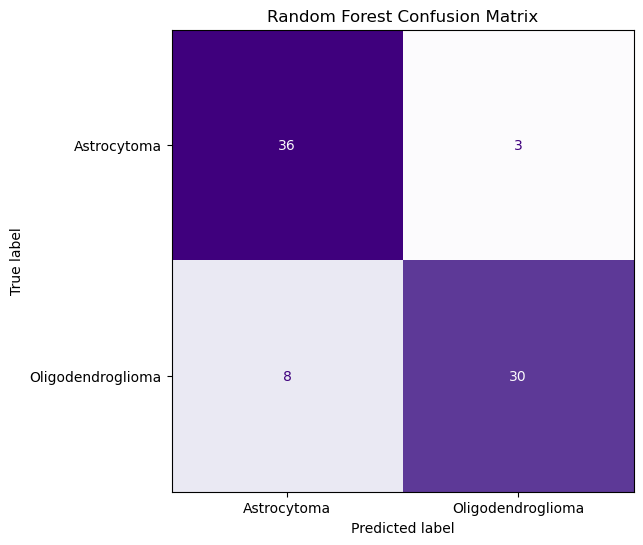

In [142]:
# Confusion Matrix

cm_rf = confusion_matrix(y_test,y_pred_rf)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm_rf,
    display_labels=["Astrocytoma","Oligodendroglioma"]

)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    cmap="Purples",
    ax=ax,
    colorbar=False
)

plt.title("Random Forest Confusion Matrix")

plt.grid(False)

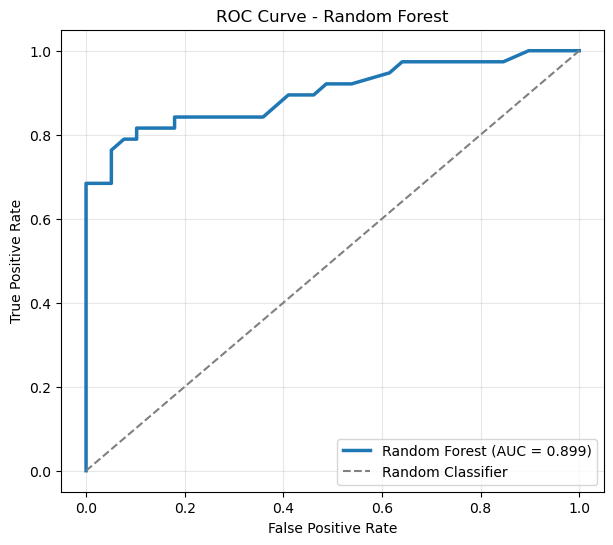

AUC Score : 0.8995


In [145]:
# Plot ROC curve

y_prob_rf = rf_model.predict_proba(X_test_selected)[:,1]

fpr_rf,tpr_rf,_ = roc_curve(y_test,y_prob_rf)

rf_auc = roc_auc_score(y_test,y_prob_rf)

plt.figure(figsize=(7,6))

plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=2.5,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Random Forest")

plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.show()

print(f"AUC Score : {rf_auc:.4f}")

In [143]:
rf_predictions = pd.DataFrame({

    "Actual":y_test,
    "Predicted":y_pred_rf

})

rf_predictions.head(20)

,Actual,Predicted
219,1,1
375,0,0
267,0,0
139,1,1
137,1,1
248,1,1
227,0,0
351,1,1
275,0,0
107,0,1


In [146]:
rf_summary = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "AUC"
    ],

    "Value":[
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_auc
    ]

})

rf_summary["Value"] = rf_summary["Value"].round(4)

rf_summary

,Metric,Value
0,Accuracy,0.8571
1,Precision,0.8630
2,Recall,0.8571
3,F1-score,0.8564
4,AUC,0.8995


In [147]:
rf_summary.to_excel(
    "RandomForest_Performance.xlsx",
    index=False
)

rf_predictions.to_excel(
    "RandomForest_Predictions.xlsx",
    index=False
)

In [148]:
# Model Comparison

comparison = pd.DataFrame({

    "Model":[
        "K-Nearest Neighbors",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy,
        dt_accuracy,
        rf_accuracy
    ],

    "Precision":[
        precision,
        dt_precision,
        rf_precision
    ],

    "Recall":[
        recall,
        dt_recall,
        rf_recall
    ],

    "F1-score":[
        f1,
        dt_f1,
        rf_f1
    ],

    "AUC":[
        auc_score,
        dt_auc,
        rf_auc
    ]

})

comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1-score,AUC
0,K-Nearest Neighbors,0.8312,0.8421,0.8312,0.8296,0.8812
1,Decision Tree,0.8312,0.8330,0.8312,0.8308,0.8327
2,Random Forest,0.8571,0.8630,0.8571,0.8564,0.8995


In [149]:
comparison.to_excel(
    "Model_Comparison.xlsx",
    index=False
)

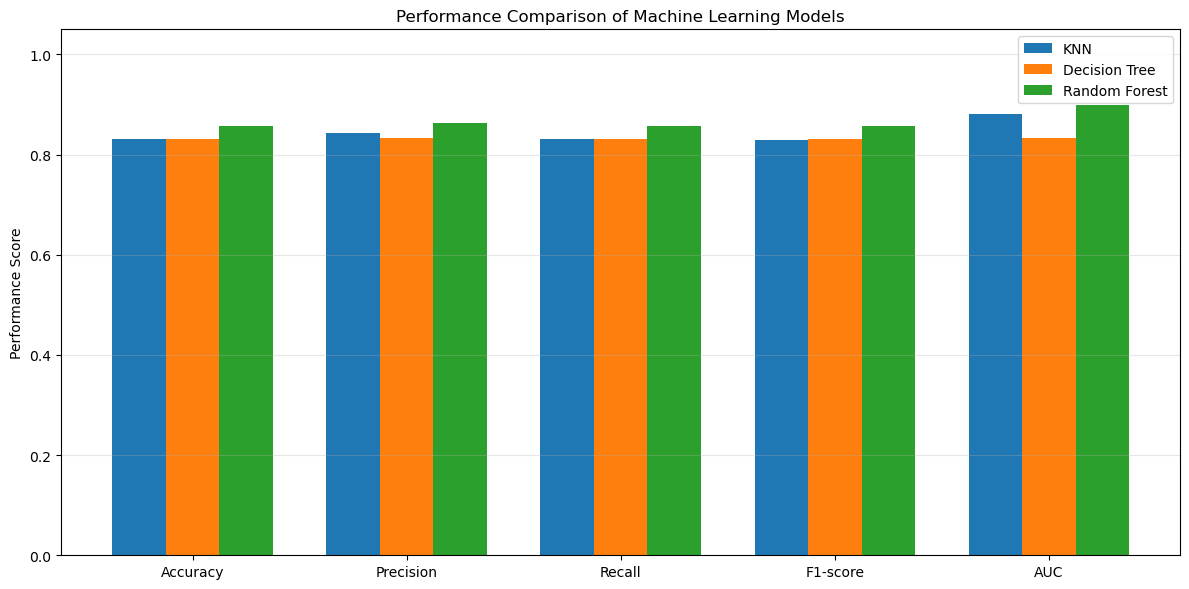

In [150]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy","Precision","Recall","F1-score","AUC"]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(12,6))

plt.bar(
    x-width,
    comparison.loc[0,metrics],
    width,
    label="KNN"
)

plt.bar(
    x,
    comparison.loc[1,metrics],
    width,
    label="Decision Tree"
)

plt.bar(
    x+width,
    comparison.loc[2,metrics],
    width,
    label="Random Forest"
)

plt.xticks(x,metrics)

plt.ylim(0,1.05)

plt.ylabel("Performance Score")

plt.title("Performance Comparison of Machine Learning Models")

plt.legend()

plt.grid(axis="y",alpha=0.3)

plt.tight_layout()

plt.show()

In [151]:

import pandas as pd
import numpy as np
import joblib # saves machine learning model and saves it later

In [159]:
joblib.dump(rf_model, "RandomForest_Model.pkl")

print("File saved:")

File saved:


In [161]:
rf_model = joblib.load(
    "RandomForest_Model.pkl"
)


In [203]:
selected_genes = X_train_selected.columns

selected_genes.to_series().to_csv(
    "Selected_500_Genes.csv",
    index=False
)


print("Selected Gene List Saved Successfully")


print(f"Number of Selected Genes : {len(selected_genes)}")

print("\nFirst 10 Selected Genes\n")
print(selected_genes[:10])

Selected Gene List Saved Successfully
Number of Selected Genes : 500

First 10 Selected Genes

Index(['ASB3', 'HDGF', 'CNOT6L', 'DOLPP1', 'GRLF1', 'FNTB', 'HSCB', 'FAM198A',
       'KCNJ8', 'C2orf79'],
      dtype='object')


In [202]:
# Load the selected genes

selected_genes = pd.read_csv(
    "Selected_500_Genes.csv"
).iloc[:, 0].tolist()

print("Selected Gene List Loaded Successfully")


print(f"Number of Required Genes : {len(selected_genes)}")

print("\nFirst 10 Required Genes\n")
print(selected_genes[:10])

Selected Gene List Loaded Successfully
Number of Required Genes : 500

First 10 Required Genes

['ASB3', 'HDGF', 'CNOT6L', 'DOLPP1', 'GRLF1', 'FNTB', 'HSCB', 'FAM198A', 'KCNJ8', 'C2orf79']


In [201]:
patient = pd.read_excel(
    "patient_1.xlsx"
)


print("Patient File Loaded Successfully")


patient.head()

Patient File Loaded Successfully


,Genes,Patient_001
0,UBE2Q2P2,8.7141
1,HMGB1P1,22.7523
2,RNU12-2P,268.5760
3,SSX9P,845.8150
4,EZHIP,0.0000


In [204]:
# Set gene names as index

patient = patient.set_index("Genes")

print(patient.head())

          Patient_001
Genes                
UBE2Q2P2       8.7141
HMGB1P1       22.7523
RNU12-2P     268.5760
SSX9P        845.8150
EZHIP          0.0000


In [205]:
# Transpose Matrix

patient = patient.T
print(patient.shape)

(1, 10000)


In [206]:
# Perform log transformation
patient = np.log2(patient + 1)

In [207]:
# verify gene availability

missing_genes = list(
    set(selected_genes) -
    set(patient.columns)
)



print(f"Required Genes : {len(selected_genes)}")
print(f"Missing Genes  : {len(missing_genes)}")

Required Genes : 500
Missing Genes  : 0


In [185]:
patient = patient[selected_genes]

print(patient.shape)

(1, 500)


In [186]:
prediction = rf_model.predict(patient)

probability = rf_model.predict_proba(patient)

In [197]:

class_labels = {
    0: "Astrocytoma",
    1: "Oligodendroglioma"
}

predicted_class = class_labels[prediction[0]]

confidence = np.max(probability) * 100

prob_astro = probability[0][0] * 100
prob_oligo = probability[0][1] * 100

In [198]:

print("Tumor Classification Report")


print(f"Patient ID              : {patient.index[0]}")
print(f"Genes Required by Model : {len(selected_genes)}")
print(f"Missing Genes           : {len(missing_genes)}")
print(f"Preprocessing Applied   : Log₂(x + 1)")
print(f"Model Used              : Random Forest")
print(f"Prediction              : {predicted_class}")
print(f"Confidence Score        : {confidence:.2f}%")

print("\nClass Probabilities")
print("-"*70)
print(f"Astrocytoma            : {prob_astro:.2f}%")
print(f"Oligodendroglioma      : {prob_oligo:.2f}%")

if confidence >= 70:
    print("\nInterpretation         : High-confidence prediction")
else:
    print("\nInterpretation         : Low-confidence prediction. Further clinical evaluation is recommended.")



Tumor Classification Report
Patient ID              : Patient_001
Genes Required by Model : 500
Missing Genes           : 0
Preprocessing Applied   : Log₂(x + 1)
Model Used              : Random Forest
Prediction              : Astrocytoma
Confidence Score        : 92.00%

Class Probabilities
----------------------------------------------------------------------
Astrocytoma            : 92.00%
Oligodendroglioma      : 8.00%

Interpretation         : High-confidence prediction
Inference Completed Successfully


In [209]:

# Deployment Phase (Decision Tree)
# Import Libraries
import pandas as pd
import numpy as np
import joblib


# Step 1: Save the Trained Decision Tree Model

joblib.dump(
    dt_model,
    "DecisionTree_Model.pkl"
)


# Step 2: Load the Trained Decision Tree Model


dt_model = joblib.load(
    "DecisionTree_Model.pkl"
)


print("Decision Tree Model Loaded Successfully")




# Step 3: Load Selected Gene List


selected_genes = pd.read_csv(
    "Selected_500_Genes.csv"
).iloc[:, 0].tolist()


print("Selected Gene List Loaded")
print(f"Number of Required Genes : {len(selected_genes)}")


# Step 4: Load New Patient


patient = pd.read_excel(
    "patient_1.xlsx"
)

print("Patient File Loaded Successfully")

print(patient.head())


# Step 5: Set Gene Names as Index


patient = patient.set_index("Genes")



# Step 6: Transpose Matrix


patient = patient.T



print("Patient Matrix Transposed")


print(f"Matrix Shape : {patient.shape}")

# Step 7: Apply Log2(x+1) Transformation


patient = np.log2(patient + 1)


print("Log2 Transformation Applied Successfully")


# Step 8: Verify Required Genes


missing_genes = list(
    set(selected_genes) - set(patient.columns)
)


print("Gene Verification")


print(f"Required Genes : {len(selected_genes)}")
print(f"Missing Genes  : {len(missing_genes)}")


    
# Step 9: Select and Arrange Required Features

patient = patient[selected_genes]




print("Feature Selection Completed")


print(f"Final Matrix Shape : {patient.shape}")



# Step 10: Predict Tumor Type


prediction = dt_model.predict(patient)

probability = dt_model.predict_proba(patient)



# Step 11: Decode Prediction


class_labels = {
    0: "Astrocytoma",
    1: "Oligodendroglioma"
}

predicted_class = class_labels[prediction[0]]

confidence = np.max(probability) * 100

prob_astro = probability[0][0] * 100
prob_oligo = probability[0][1] * 100

Decision Tree Model Loaded Successfully
Selected Gene List Loaded
Number of Required Genes : 500
Patient File Loaded Successfully
      Genes  Patient_001
0  UBE2Q2P2       8.7141
1   HMGB1P1      22.7523
2  RNU12-2P     268.5760
3     SSX9P     845.8150
4     EZHIP       0.0000
Patient Matrix Transposed
Matrix Shape : (1, 10000)
Log2 Transformation Applied Successfully
Gene Verification
Required Genes : 500
Missing Genes  : 0
Feature Selection Completed
Final Matrix Shape : (1, 500)


In [208]:
print("Tumor Classification Report")


print(f"Patient ID              : {patient.index[0]}")
print(f"Genes Required by Model : {len(selected_genes)}")
print(f"Missing Genes           : {len(missing_genes)}")
print(f"Preprocessing Applied   : Log₂(x + 1)")
print(f"Model Used              : Decision Tree")
print(f"Prediction              : {predicted_class}")
print(f"Confidence Score        : {confidence:.2f}%")

print("\nClass Probabilities")
print("-"*70)
print(f"Astrocytoma            : {prob_astro:.2f}%")
print(f"Oligodendroglioma      : {prob_oligo:.2f}%")

if confidence >= 70:
    print("\nInterpretation         : High-confidence prediction")
else:
    print("\nInterpretation         : Low-confidence prediction. Further clinical evaluation is recommended.")

Tumor Classification Report
Patient ID              : Patient_001
Genes Required by Model : 500
Missing Genes           : 0
Preprocessing Applied   : Log₂(x + 1)
Model Used              : Decision Tree
Prediction              : Astrocytoma
Confidence Score        : 98.11%

Class Probabilities
----------------------------------------------------------------------
Astrocytoma            : 98.11%
Oligodendroglioma      : 1.89%

Interpretation         : High-confidence prediction
